In [44]:
import numpy as np
import maglab
import torch
import numpy as np
import h5py

In [ ]:
m0 = np.load("./m/r-'136'1e-9-ku-'0'1e2-H-'0'.npy")

geo = maglab.geo.cylider(136, 110)
nx, ny, nz = geo.shape
m0 = m0.reshape(3, nx, ny, nz, order='F')
m0 = torch.from_numpy(m0).cuda()
N = 206
dx = 1.06e-9
Ms = 3.84e5
phasemapper = maglab.PhaseMapper(N, dx, rotation_padding=N).cuda()
angles = [0, 28, 44, 50, 54, 58, 61, 65]

(<Figure size 1500x500 with 6 Axes>,
 array([<Axes: title={'center': 'mx'}>, <Axes: title={'center': 'my'}>,
        <Axes: title={'center': 'mz'}>], dtype=object))

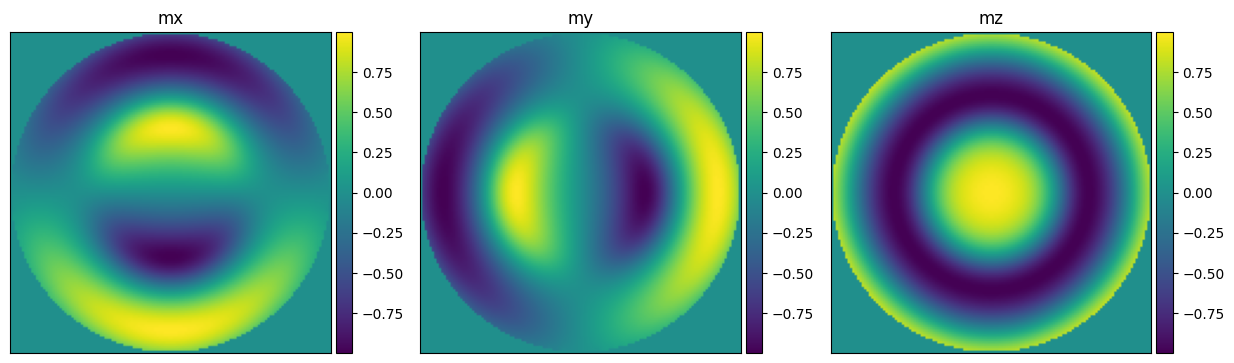

In [41]:
micro = maglab.Micro(nx, ny, nz, dx)
A = 4.75e-12 
D = 8.53e-4
micro.set_Ms(geo * Ms)
micro.add_exch(A)
micro.add_dmi(D)
micro.add_demag()
micro.cuda()
micro.init_m0(m0)
spin = micro.get_spin().detach().cpu().numpy()
maglab.display.show_list([spin[i, :, :, nz//2] for i in range(3)], 
                                titles=["mx", "my", "mz"])
# plt.savefig("./init_spin.jpg")

In [42]:
phaseset = maglab.dataset.PhaseSet()
for alpha in angles:
    phasemap = phasemapper(m0, alpha=-alpha, Ms=Ms)
    phasemap = maglab.dataset.PhaseMap(phasemap, alpha=alpha)
    # phasemap = phasemap.add_Gaussian(sigma=0.1)
    phaseset.load(phasemap)
phaseset.sort()

(<Figure size 2000x1000 with 16 Axes>,
 array([[<Axes: title={'center': '(0, 0.0, 0.0)'}>,
         <Axes: title={'center': '(28, 0.0, 0.0)'}>,
         <Axes: title={'center': '(44, 0.0, 0.0)'}>,
         <Axes: title={'center': '(50, 0.0, 0.0)'}>],
        [<Axes: title={'center': '(54, 0.0, 0.0)'}>,
         <Axes: title={'center': '(58, 0.0, 0.0)'}>,
         <Axes: title={'center': '(61, 0.0, 0.0)'}>,
         <Axes: title={'center': '(65, 0.0, 0.0)'}>]], dtype=object))

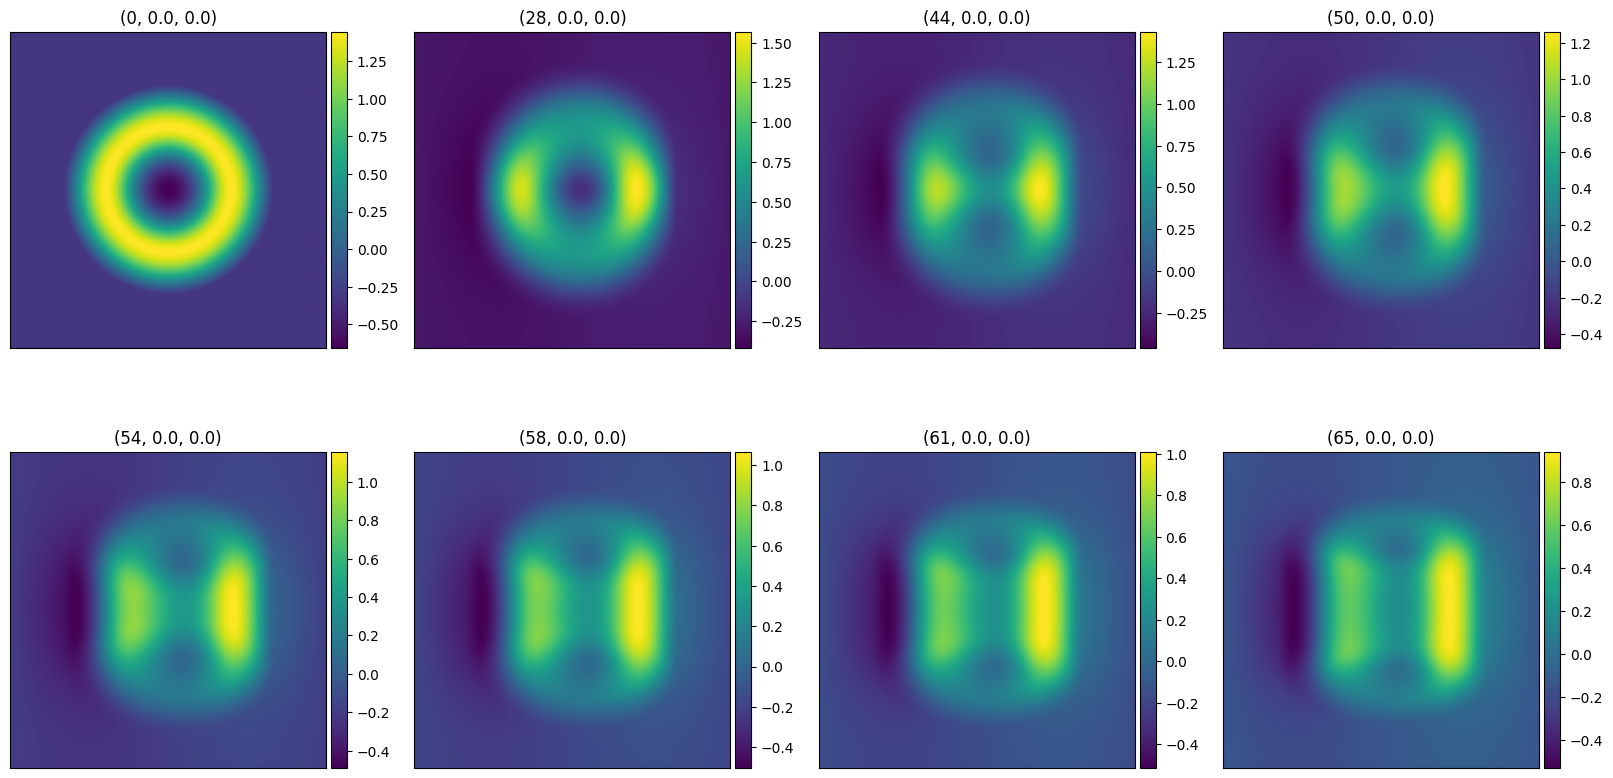

In [43]:
maglab.display.show_list([x.data.cpu().numpy() for x in phaseset], 
                         titles = [x.Euler for x in phaseset],
                         rows=2, same_colorbar=False)